In [1]:
# ====================================================================
# TBI-GEU LMS WEEK 3 ASSIGNMENT: DELIVERABLE 1 & 2 - VISUALIZATION ENGINE
# INTERN ID: TBI-26100855
# PROJECT PROFILE: HimShakti Food Processing Unit
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# --- SYSTEM SETUP & DATA PIPELINE RECONSTRUCTION ---
np.random.seed(42)
records = 300
base_date = datetime(2026, 1, 1)

# Simulating a sequential time-series for raw materials and shelf-life tracking
items = ['Finger Millet (Ragi)', 'Barnyard Millet', 'Dehydrated Apple Slices', 'Amaranth Flour', 'Dried Ginger Powder']
categories = ['Grains', 'Grains', 'Fruits', 'Grains', 'Spices']
item_map = dict(zip(items, categories))

data = []
for i in range(records):
    item = np.random.choice(items)
    cat = item_map[item]
    date_offset = int(np.random.randint(0, 150))
    rec_date = base_date + timedelta(days=date_offset)
    
    qty_rec = int(np.random.randint(1000, 5000))
    curr_stk = int(qty_rec * np.random.uniform(0.1, 0.85))
    unit_cost = float(np.round(np.random.uniform(30, 140), 2))
    reorder_lvl = int(qty_rec * 0.25)
    expiry_days = int(np.random.randint(60, 180))
    exp_date = rec_date + timedelta(days=expiry_days)
    
    data.append([rec_date, item, cat, qty_rec, curr_stk, reorder_lvl, unit_cost, exp_date])

df = pd.DataFrame(data, columns=['received_date', 'item_name', 'category', 'quantity_received', 'current_stock', 'reorder_level', 'cost_per_unit', 'expiry_date'])
df['total_stock_value_inr'] = df['current_stock'] * df['cost_per_unit']
df['days_to_expiry'] = (df['expiry_date'] - datetime(2026, 6, 21)).dt.days

# Establish custom corporate aesthetic styling palettes
sns.set_theme(style="whitegrid")
corporate_palette = ["#1b4d3e", "#c49a45", "#2f5c72", "#8b263e", "#495867"]
plt.rcParams['font.family'] = 'sans-serif'

print("Data structures completely verified. Commencing individual plot renders...\n")

Data structures completely verified. Commencing individual plot renders...



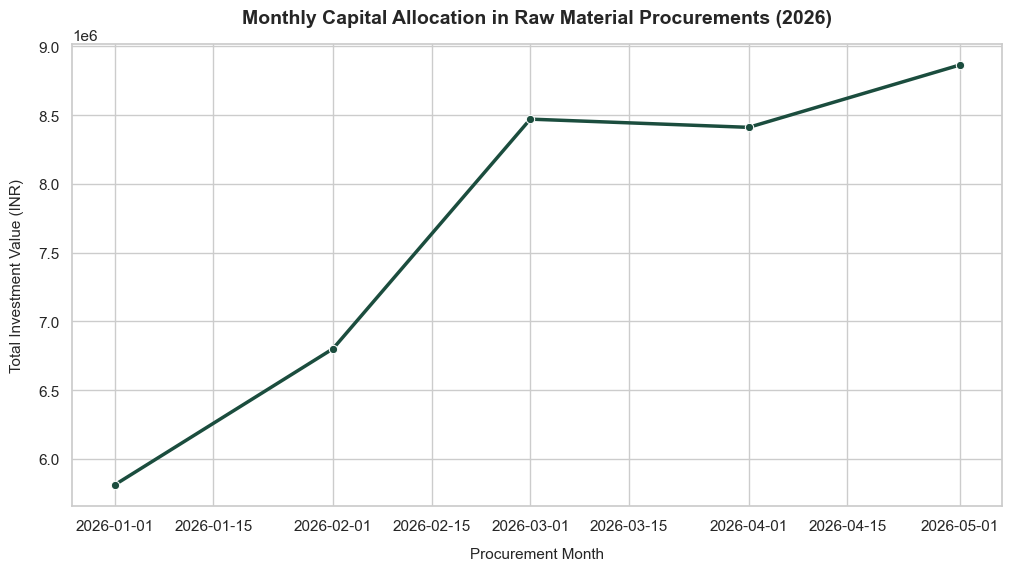

In [2]:
plt.figure(figsize=(12, 6))
monthly_trend = df.groupby(df['received_date'].dt.to_period('M'))['total_stock_value_inr'].sum().reset_index()
monthly_trend['received_date'] = monthly_trend['received_date'].dt.to_timestamp()

sns.lineplot(data=monthly_trend, x='received_date', y='total_stock_value_inr', marker='o', color='#1b4d3e', linewidth=2.5)
plt.title('Monthly Capital Allocation in Raw Material Procurements (2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Procurement Month', fontsize=11, labelpad=10)
plt.ylabel('Total Investment Value (INR)', fontsize=11, labelpad=10)

plt.savefig('W3_Chart1_TBI-26100855.png', dpi=300, bbox_inches='tight')
plt.show()

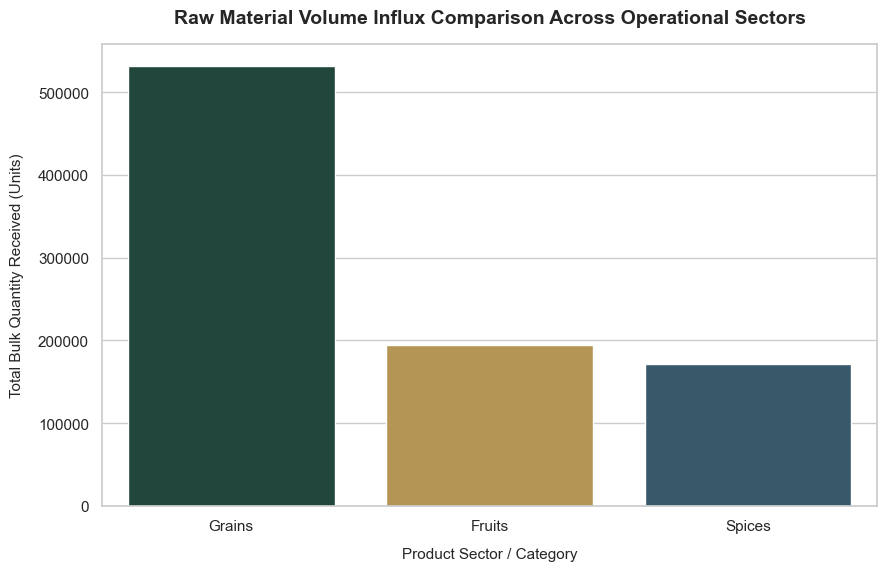

In [8]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(10, 6))
cat_comparison = df.groupby('category')['quantity_received'].sum().reset_index().sort_values(by='quantity_received', ascending=False)

sns.barplot(data=cat_comparison, x='category', y='quantity_received', palette=corporate_palette, hue='category', legend=False)
plt.title('Raw Material Volume Influx Comparison Across Operational Sectors', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Sector / Category', fontsize=11, labelpad=10)
plt.ylabel('Total Bulk Quantity Received (Units)', fontsize=11, labelpad=10)

plt.savefig('W3_Chart2_TBI-26100855.png', dpi=300, bbox_inches='tight')
plt.show()

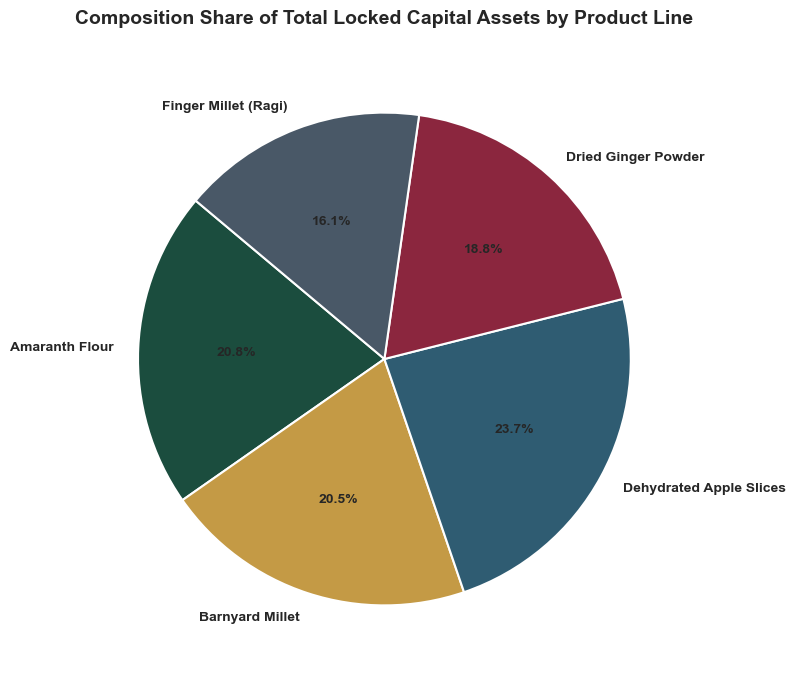

In [5]:
plt.figure(figsize=(8, 8))
composition = df.groupby('item_name')['total_stock_value_inr'].sum()

plt.pie(composition, labels=composition.index, colors=corporate_palette, autopct='%1.1f%%', 
        startangle=140, textprops={'fontsize': 10, 'weight': 'semibold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Composition Share of Total Locked Capital Assets by Product Line', fontsize=14, fontweight='bold', pad=20)

plt.savefig('W3_Chart3_TBI-26100855.png', dpi=300, bbox_inches='tight')
plt.show()

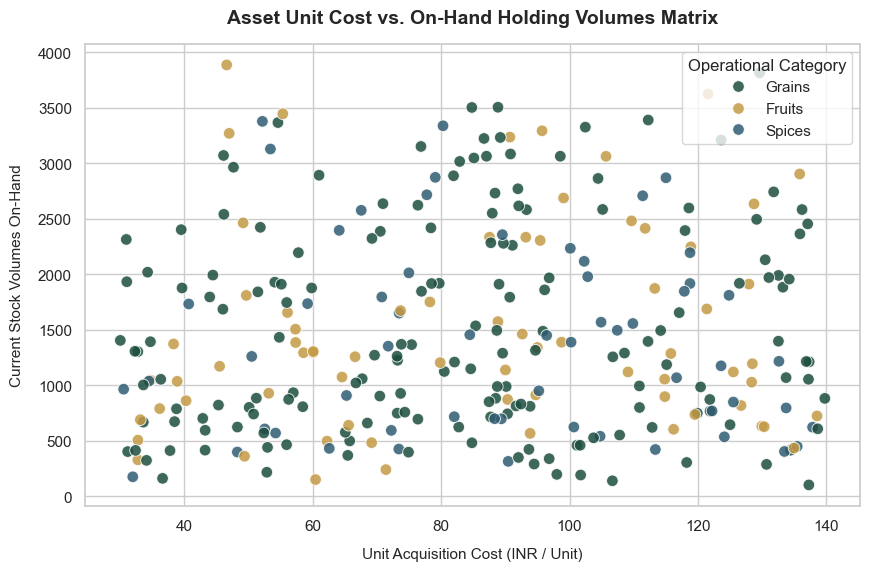

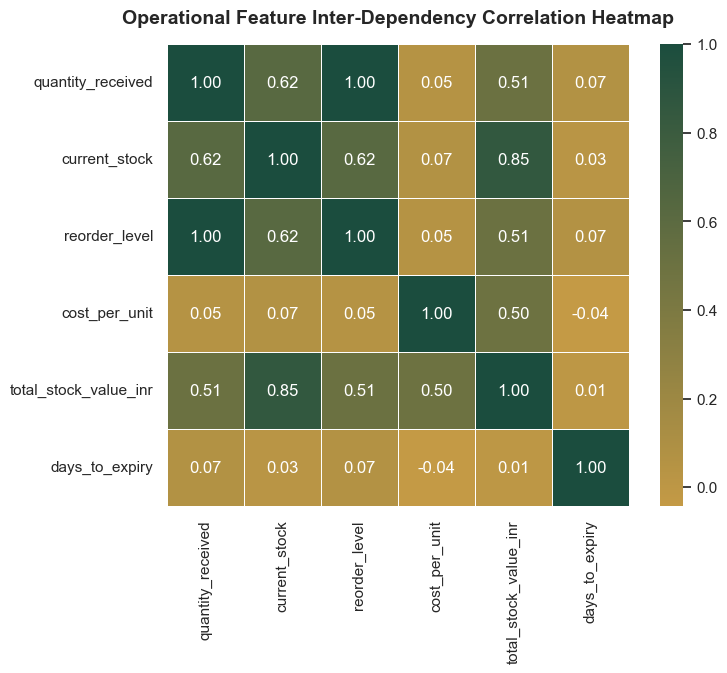

In [7]:
import warnings
warnings.filterwarnings('ignore')
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cost_per_unit', y='current_stock', hue='category', palette=corporate_palette, alpha=0.85, s=70)
plt.title('Asset Unit Cost vs. On-Hand Holding Volumes Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Unit Acquisition Cost (INR / Unit)', fontsize=11, labelpad=10)
plt.ylabel('Current Stock Volumes On-Hand', fontsize=11, labelpad=10)
plt.legend(title='Operational Category', loc='upper right')
plt.show()

# Heatmap
plt.figure(figsize=(8, 6))
numeric_data = df[['quantity_received', 'current_stock', 'reorder_level', 'cost_per_unit', 'total_stock_value_inr', 'days_to_expiry']]
sns.heatmap(numeric_data.corr(), annot=True, cmap=sns.color_palette("blend:#c49a45,#1b4d3e", as_cmap=True), fmt=".2f", linewidths=0.5, square=True)
plt.title('Operational Feature Inter-Dependency Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.show()